# Oracle routing analysis

**Can per-sample modality routing beat simply always using the best fixed
configuration?** If it cannot, the adaptive-routing contribution does not exist,
and this notebook says so cheaply — before any gate is built.

The modality ablation established the two tiers:

| tier | configuration | GFLOPs | DBA |
|---|---|---|---|
| cheap | GPS | 0.39 | 0.7298 |
| escalate | GPS + Camera | 48.2 | 0.8835 |

A 124× cost ratio with +0.154 DBA of headroom. The question is how much of that
headroom a router can actually capture.

## What this computes

1. **Oracle ceiling.** Escalate only where the cheap tier is wrong *and* the
   expensive tier is right. Uses ground truth, so it is unachievable — it is the
   upper bound on any router.
2. **Realisable gate.** Escalate the least-confident fraction, using only the
   cheap model's own output. Sweeping the threshold traces an
   accuracy-versus-compute curve that a real system could follow.
3. **The decisive comparison.** Does that curve pass above the *always
   GPS + Camera* point? Reaching the same DBA at materially less average compute
   is the contribution; needing ~all samples escalated means there is none.
4. **Whether difficulty is the right gate signal.** AUC of the target-derived
   ambiguity measures for predicting "cheap suffices", against the AUC of the
   cheap model's own confidence. Difficulty is computed from the power vector and
   is **offline only** — a deployed gate cannot see it.

No training. A GPU is used only for step 0, turning checkpoints into per-sample
predictions.

## What to attach

The ablation checkpoints, as a Kaggle dataset, plus the preprocessed dataset.
Checkpoints are found by walking `/kaggle/input`, in either layout:

- `.../<slug>/best.pt` — a directory named for the configuration, e.g.
  `runs/gps_image/best.pt`
- `.../<slug>.pt` — the file itself renamed, e.g. `gps_image.pt`

**Do not flatten eight files all called `best.pt` into one folder** — they would
collide and the configuration would be unrecoverable. Either keep the
`runs/<slug>/` directories or rename to `<slug>.pt`.

At minimum the cheap and one expensive configuration must be present. Anything
missing is reported and skipped.

## 1. Configuration

In [22]:
from pathlib import Path

# The two tiers, as the ablation identified them. Slugs match the run directories.
CHEAP = "gps"                  # GPS only          0.39 GFLOPs
EXPENSIVE = "gps_image"        # GPS + Camera     48.24 GFLOPs

SPLIT = "val"                  # the labelled split with real n (2,198)
SECONDARY_SPLIT = "adaptation" # 100 samples, includes the unseen scenario 31

BATCH_SIZE = 32
WORKERS = 2
TOPK = 5

OUT = Path("/kaggle/working/outputs/oracle_routing")
(OUT / "plots").mkdir(parents=True, exist_ok=True)
(OUT / "predictions").mkdir(parents=True, exist_ok=True)

# GFLOPs per configuration, measured during the ablation. Used for the cost model.
GFLOPS = {
    "gps": 0.3869, "gps_radar": 23.5668, "gps_lidar": 23.0530,
    "gps_radar_lidar": 46.2328, "gps_image": 48.2398,
    "gps_image_lidar": 70.9058, "gps_radar_image": 71.4196,
    "gps_radar_image_lidar": 94.0856,
}
DBA_DELTA = 5.0                # the Delta in eqs. (38)-(39)

print(f"cheap tier     {CHEAP:<24} {GFLOPS[CHEAP]:>7.2f} GFLOPs")
print(f"escalate to    {EXPENSIVE:<24} {GFLOPS[EXPENSIVE]:>7.2f} GFLOPs")
print(f"cost ratio     {GFLOPS[EXPENSIVE] / GFLOPS[CHEAP]:.0f}x")
print(f"outputs ->     {OUT}")

cheap tier     gps                         0.39 GFLOPs
escalate to    gps_image                  48.24 GFLOPs
cost ratio     125x
outputs ->     /kaggle/working/outputs/oracle_routing


## 2. Environment

In [23]:
import os
import socket
import subprocess
import sys

import torch

print(f"torch {torch.__version__}   cuda: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_properties(0).name}")
else:
    print("No GPU. Prediction will be slow; the analysis itself needs none.")


def has_internet(host="github.com", port=443, timeout=6):
    try:
        socket.create_connection((host, port), timeout=timeout).close()
        return True
    except OSError:
        return False


assert has_internet(), "Internet is off; the code cannot be cloned."
print("internet: on")

torch 2.10.0+cu128   cuda: True
GPU: Tesla T4
internet: on


## 3. Dataset and code

In [24]:
import shutil

import pandas as pd

INPUT_ROOT = Path("/kaggle/input")
SOURCES = ("development", "adaptation", "test")


def walk_dirs(base, follow=True):
    for dirpath, dirnames, filenames in os.walk(base, followlinks=follow):
        yield Path(dirpath), dirnames, filenames


def find_index(base):
    '''The index directory, chosen deliberately when several are attached.

    A results dataset from a training run contains its own copy of
    data/processed_amber/index, so more than one samples.csv can be present.
    Taking the first one found would depend on walk order, so instead prefer the
    index that sits alongside the actual scenario tensors -- the copy inside a
    results dump has no development/adaptation/test beside it.
    '''
    hits = []
    for cand in (base / "index" / "index", base / "index"):
        if (cand / "samples.csv").exists():
            hits.append(cand)
    for d, _dirs, files in walk_dirs(base):
        if "samples.csv" in files and d not in hits:
            hits.append(d)
    if not hits:
        return None
    def score(h):
        roots = [h.parent, h.parent.parent, h]
        return sum(1 for s in SOURCES
                   if any(find_source(r, s) is not None for r in roots))
    ranked = sorted(hits, key=score, reverse=True)
    if len(hits) > 1:
        print(f"{len(hits)} index copies attached; using the one co-located with "
              f"the tensors:")
        for h in ranked:
            print(f"  {'->' if h is ranked[0] else '  '} {score(h)}/3 sources  {h}")
    return ranked[0]


def find_source(base, name):
    for cand in (base / name / name, base / name):
        if cand.is_dir() and any(cand.glob("scenario*")):
            return cand
    return None


INDEX_SRC = find_index(INPUT_ROOT)
assert INDEX_SRC is not None, "samples.csv not found under /kaggle/input"
ROOTS = [INDEX_SRC.parent, INDEX_SRC.parent.parent, INDEX_SRC]
SOURCE_DIRS = {s: next((d for d in (find_source(r, s) for r in ROOTS) if d), None)
               for s in SOURCES}
for s in [k for k, v in SOURCE_DIRS.items() if v is None]:
    for d, dn, _f in walk_dirs(INPUT_ROOT):
        if d.name == s and any(n.startswith("scenario") for n in dn):
            SOURCE_DIRS[s] = d
            break

# Stage idempotently. /kaggle/working survives between cell runs, so anything
# left by an earlier execution must be validated rather than trusted: a stale
# index copy, or a symlink pointing at a different dataset, would otherwise be
# silently reused and surface much later as a missing file.
STAGE = Path("/kaggle/working/data/processed_amber")
STAGE.mkdir(parents=True, exist_ok=True)
INDEX_DIR = STAGE / "index"

staged_csv, source_csv = INDEX_DIR / "samples.csv", INDEX_SRC / "samples.csv"
if not staged_csv.exists():
    shutil.copytree(INDEX_SRC, INDEX_DIR, dirs_exist_ok=True)
    print(f"staged index from {INDEX_SRC}")
elif staged_csv.stat().st_size != source_csv.stat().st_size:
    # a different index was staged previously -- replace it
    print(f"staged index differs from {INDEX_SRC} "
          f"({staged_csv.stat().st_size} vs {source_csv.stat().st_size} bytes); re-staging")
    shutil.rmtree(INDEX_DIR)
    shutil.copytree(INDEX_SRC, INDEX_DIR, dirs_exist_ok=True)
else:
    print("staged index already matches the chosen source")

for name, src in SOURCE_DIRS.items():
    if src is None:
        continue
    link = STAGE / name
    # os.path.islink, not .exists(): a broken symlink reports False for exists()
    if link.is_symlink():
        try:
            same = link.resolve(strict=True) == src.resolve(strict=True)
        except OSError:
            same = False            # dangling
        if not same:
            print(f"re-pointing {name}: was {os.readlink(link)}")
            link.unlink()
    elif link.exists():
        print(f"replacing non-symlink {link}")
        shutil.rmtree(link)
    if not link.exists():
        link.symlink_to(src)
    print(f"  {name:<12} -> {link.resolve()}")

REPO = "https://github.com/SathishAdithiyaaSV/MultiModal-Beam-Prediction.git"
PROJECT = Path("/kaggle/working/project")
if not (PROJECT / "amber" / "model.py").exists():
    r = subprocess.run(["git", "clone", "--depth", "1", REPO, str(PROJECT)],
                       capture_output=True, text=True,
                       env={**os.environ, "GIT_TERMINAL_PROMPT": "0"})
    assert r.returncode == 0, (r.stderr or "")[:400]
os.chdir(PROJECT)
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

from amber.ablation import config_label, parse_modalities
from amber.config import TrainConfig
from amber.difficulty import load_with_difficulty
from amber.predict import load_checkpoint, predict_split
from amber.train import pick_device

print(f"index {INDEX_DIR}")
print(f"code  {PROJECT}")

# Verify the staged data against the index before spending GPU time. An
# incomplete dataset upload leaves samples.csv claiming files that are not
# there, which would otherwise surface much later as a FileNotFoundError from
# deep inside the loader.
_s = pd.read_csv(INDEX_DIR / "samples.csv")
ROOT_DIR = INDEX_DIR.parents[2]
GROUPS = [("image", "m_image"), ("lidar_bev", "m_lidar"), ("radar", "m_radar")]
print(f"\n{'split':<14}{'rows':>7}{'checked':>9}{'missing':>9}")
problems = {}
for split in (SPLIT, SECONDARY_SPLIT):
    rows = _s[_s.split == split]
    probe = rows.sample(min(40, len(rows)), random_state=0)
    miss, n_checked = [], 0
    for _i, r in probe.iterrows():
        for prefix, mask_col in GROUPS:
            if not r[mask_col]:
                continue
            for k in range(1, 6):
                n_checked += 1
                if not (ROOT_DIR / r[f"{prefix}_{k}"]).exists():
                    miss.append((r.sample_id, f"{prefix}_{k}", r[f"{prefix}_{k}"]))
    print(f"{split:<14}{len(rows):>7}{n_checked:>9}{len(miss):>9}")
    if miss:
        problems[split] = miss

if problems:
    print("\nMISSING FILES -- the attached dataset does not match its index:")
    for split, items in problems.items():
        for sid, col, path in items[:6]:
            print(f"  {split}: {sid}  {col}")
            print(f"      {path}")
        if len(items) > 6:
            print(f"  ... and {len(items) - 6} more in {split}")
    raise SystemExit(
        "The dataset upload is incomplete: samples.csv references files that are "
        "not present. Re-upload the affected source, or attach the dataset "
        "version the ablation was run against. Run "
        "notebooks/kaggle_input_report.py for a per-directory file count.")
print("\nstaged data matches the index")

2 index copies attached; using the one co-located with the tensors:
  -> 3/3 sources  /kaggle/input/datasets/rakshithsrinivasan04/deepsense-preprocessed-dataset/index/index
     0/3 sources  /kaggle/input/datasets/sat2oo5/ablation-1-dataset/data/processed_amber/index
staged index already matches the chosen source
  development  -> /kaggle/input/datasets/rakshithsrinivasan04/deepsense-preprocessed-dataset/development/development
  adaptation   -> /kaggle/input/datasets/rakshithsrinivasan04/deepsense-preprocessed-dataset/adaptation/adaptation
  test         -> /kaggle/input/datasets/rakshithsrinivasan04/deepsense-preprocessed-dataset/test/test
index /kaggle/working/data/processed_amber/index
code  /kaggle/working/project

split            rows  checked  missing
val              2198      555        0
adaptation        100      600        0

staged data matches the index


## 4. Find the ablation checkpoints

Configuration is taken from the run directory name, since checkpoints written
before this notebook existed record only the global modality list. Newer ones
carry `enabled_modalities` and that is preferred when present.

In [25]:
KNOWN = set(GFLOPS)


def discover_checkpoints():
    '''Locate one checkpoint per configuration, tolerating either upload layout.

    Accepts both shapes, since flattening eight files all named best.pt into one
    folder would collide:
        .../<slug>/best.pt      directory named for the configuration
        .../<slug>.pt           file renamed to the configuration
    '''
    found = {}
    for d, _dirs, files in walk_dirs(INPUT_ROOT):
        # layout A: a directory named for the configuration
        if "best.pt" in files and d.name in KNOWN:
            found.setdefault(d.name, d / "best.pt")
        # layout B: files renamed to <slug>.pt
        for name in files:
            if name.endswith(".pt") and name[:-3] in KNOWN:
                found.setdefault(name[:-3], d / name)
    return found


CKPTS = discover_checkpoints()
print(f"{len(CKPTS)}/8 checkpoints found\n")
for slug in GFLOPS:
    if slug in CKPTS:
        print(f"  {slug:<24} {CKPTS[slug]}")
    else:
        print(f"  {slug:<24} -- missing")

missing_core = [s for s in (CHEAP, EXPENSIVE) if s not in CKPTS]
if missing_core:
    raise SystemExit(
        f"The core tiers {missing_core} are missing, so the central question cannot "
        f"be answered. Attach the ablation checkpoints -- part 1 supplies "
        f"'{CHEAP}', part 2 supplies '{EXPENSIVE}'.")

8/8 checkpoints found

  gps                      /kaggle/input/datasets/sat2oo5/ablation-1-dataset/outputs/modality_ablation/runs/gps/best.pt
  gps_radar                /kaggle/input/datasets/sat2oo5/ablation-1-dataset/outputs/modality_ablation/runs/gps_radar/best.pt
  gps_lidar                /kaggle/input/datasets/rakshithsrinivasan04/ablation-2-results/ablation_part2_ckpts/gps_lidar.pt
  gps_radar_lidar          /kaggle/input/datasets/rakshithsrinivasan04/ablation-2-results/ablation_part2_ckpts/gps_radar_lidar.pt
  gps_image                /kaggle/input/datasets/rakshithsrinivasan04/ablation-2-results/ablation_part2_ckpts/gps_image.pt
  gps_image_lidar          /kaggle/input/datasets/rakshithsrinivasan04/ablation-2-results/ablation_part2_ckpts/gps_image_lidar.pt
  gps_radar_image          /kaggle/input/datasets/sat2oo5/ablation-1-dataset/outputs/modality_ablation/runs/gps_radar_image/best.pt
  gps_radar_image_lidar    /kaggle/input/datasets/sat2oo5/ablation-1-dataset/outputs/modali

## 5. Per-sample predictions

The only GPU step. `--modalities` is essential: without it a configuration's
checkpoint would be scored against whatever modalities each sample happens to
have, silently evaluating a different model. Results are cached, so re-running
is free.

In [26]:
import gc

device = pick_device("auto")
train_cfg = TrainConfig()


def predictions_for(slug, split):
    '''Per-sample predictions for one configuration, cached to disk.'''
    cache = OUT / "predictions" / f"{split}_{slug}.csv"
    if cache.exists():
        return pd.read_csv(cache)
    mods = parse_modalities(slug.split("_"))
    model, cfg = load_checkpoint(CKPTS[slug], device)
    frame, _metrics = predict_split(model, INDEX_DIR, split, cfg, train_cfg, device,
                                    BATCH_SIZE, WORKERS, TOPK, modalities=mods)
    frame["slug"] = slug
    frame.to_csv(cache, index=False)
    del model
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
    print(f"  {config_label(mods):<32} {len(frame)} samples -> {cache.name}")
    return frame


preds = {}
for split in (SPLIT, SECONDARY_SPLIT):
    print(f"\n{split}:")
    preds[split] = {s: predictions_for(s, split) for s in CKPTS}
print("\ndone")


val:
  GPS + LiDAR                      2198 samples -> val_gps_lidar.csv
  GPS + Camera + LiDAR             2198 samples -> val_gps_image_lidar.csv
  GPS + Camera                     2198 samples -> val_gps_image.csv
  GPS + Radar + LiDAR              2198 samples -> val_gps_radar_lidar.csv
  GPS + Radar                      2198 samples -> val_gps_radar.csv
  GPS                              2198 samples -> val_gps.csv
  GPS + Radar + Camera             2198 samples -> val_gps_radar_image.csv
  GPS + Radar + Camera + LiDAR     2198 samples -> val_gps_radar_image_lidar.csv

adaptation:
  GPS + LiDAR                      100 samples -> adaptation_gps_lidar.csv
  GPS + Camera + LiDAR             100 samples -> adaptation_gps_image_lidar.csv
  GPS + Camera                     100 samples -> adaptation_gps_image.csv
  GPS + Radar + LiDAR              100 samples -> adaptation_gps_radar_lidar.csv
  GPS + Radar                      100 samples -> adaptation_gps_radar.csv
  GPS             

## 6. Per-sample correctness and DBA

DBA is an average of per-sample terms, so it decomposes exactly:

    per-sample DBA = mean over k=1..3 of ( 1 - min( min_{k'<=k} |y - yhat_k'| / Delta , 1 ) )

which lets a routed mixture be scored without re-running any model.

In [27]:
import numpy as np


def per_sample_scores(frame, topk=3, delta=DBA_DELTA):
    '''Adds correct@1, correct@3 and a per-sample DBA contribution.'''
    f = frame.copy()
    beams = np.stack([f[f"top{k}_beam"].to_numpy() for k in range(1, topk + 1)], axis=1)
    true = f["true_beam"].to_numpy()[:, None]
    f["correct1"] = (beams[:, 0] == true[:, 0]).astype(int)
    f["correct3"] = (beams[:, :3] == true).any(axis=1).astype(int)
    dist = np.abs(beams - true) / delta
    best = np.minimum.accumulate(dist, axis=1).clip(max=1.0)
    f["dba"] = (1.0 - best).mean(axis=1)
    return f


def build_matrix(split):
    '''sample_id x configuration, for correctness, DBA and cheap-tier confidence.'''
    parts = []
    for slug, frame in preds[split].items():
        f = per_sample_scores(frame)
        parts.append(f[["sample_id", "scenario", "true_beam", "top1_beam", "top1_conf",
                        "correct1", "correct3", "dba"]].assign(slug=slug))
    long = pd.concat(parts, ignore_index=True)
    wide = long.pivot_table(index=["sample_id", "scenario"], columns="slug",
                            values=["correct1", "correct3", "dba", "top1_conf"])
    wide.columns = [f"{a}__{b}" for a, b in wide.columns]
    return long, wide.reset_index()


long_val, M = build_matrix(SPLIT)
diff = load_with_difficulty(INDEX_DIR)
M = M.merge(diff[["sample_id", "margin_db", "entropy_bits", "n_within_10pct",
                  "spread_db"]], on="sample_id", how="left")
M.to_csv(OUT / f"per_sample_{SPLIT}.csv", index=False)

print(f"{len(M)} samples x {len(CKPTS)} configurations\n")
print("sanity check -- per-sample means must reproduce the ablation's aggregates:")
for slug in CKPTS:
    print(f"  {slug:<24} Top-1 {M[f'correct1__{slug}'].mean():.4f}   "
          f"Top-3 {M[f'correct3__{slug}'].mean():.4f}   "
          f"DBA {M[f'dba__{slug}'].mean():.4f}")

2198 samples x 8 configurations

sanity check -- per-sample means must reproduce the ablation's aggregates:
  gps_lidar                Top-1 0.3449   Top-3 0.6547   DBA 0.7770
  gps_image_lidar          Top-1 0.4377   Top-3 0.7962   DBA 0.8727
  gps_image                Top-1 0.4604   Top-3 0.8139   DBA 0.8835
  gps_radar_lidar          Top-1 0.3640   Top-3 0.6984   DBA 0.8025
  gps_radar                Top-1 0.3521   Top-3 0.6665   DBA 0.7794
  gps                      Top-1 0.3203   Top-3 0.6142   DBA 0.7298
  gps_radar_image          Top-1 0.4431   Top-3 0.8139   DBA 0.8789
  gps_radar_image_lidar    Top-1 0.4399   Top-3 0.8103   DBA 0.8759


## 7. Oracle ceiling

How much headroom exists at all? Partition the samples by what the two tiers get
right.

In [28]:
c_ok = M[f"correct1__{CHEAP}"].astype(bool)
e_ok = M[f"correct1__{EXPENSIVE}"].astype(bool)

quad = pd.Series({
    "both correct": int((c_ok & e_ok).sum()),
    "cheap only": int((c_ok & ~e_ok).sum()),
    "expensive only (escalation pays)": int((~c_ok & e_ok).sum()),
    "neither": int((~c_ok & ~e_ok).sum()),
})
print("Top-1 agreement between the tiers:\n")
print((quad / len(M) * 100).round(1).astype(str).add(" %").to_string())
print(f"\nn = {len(M)}")

cheap_acc, exp_acc = c_ok.mean(), e_ok.mean()
oracle_acc = (c_ok | e_ok).mean()
# escalate only where it is both necessary and sufficient
escalate_need = (~c_ok & e_ok)
f_oracle = escalate_need.mean()
cost_oracle = GFLOPS[CHEAP] + f_oracle * (GFLOPS[EXPENSIVE] - GFLOPS[CHEAP])

print(f"\nalways cheap        Top-1 {cheap_acc:.4f}   {GFLOPS[CHEAP]:>6.2f} GFLOPs")
print(f"always expensive    Top-1 {exp_acc:.4f}   {GFLOPS[EXPENSIVE]:>6.2f} GFLOPs")
print(f"ORACLE router       Top-1 {oracle_acc:.4f}   {cost_oracle:>6.2f} GFLOPs "
      f"(escalates {f_oracle*100:.1f}% of samples)")
print(f"\nThe oracle beats always-expensive by {oracle_acc - exp_acc:+.4f} Top-1 at "
      f"{cost_oracle / GFLOPS[EXPENSIVE] * 100:.0f}% of its compute.")
print("It is an unachievable upper bound -- it consults the ground truth to decide.")

Top-1 agreement between the tiers:

both correct                        23.1 %
cheap only                           8.9 %
expensive only (escalation pays)    22.9 %
neither                             45.0 %

n = 2198

always cheap        Top-1 0.3203     0.39 GFLOPs
always expensive    Top-1 0.4604    48.24 GFLOPs
ORACLE router       Top-1 0.5496    11.36 GFLOPs (escalates 22.9% of samples)

The oracle beats always-expensive by +0.0892 Top-1 at 24% of its compute.
It is an unachievable upper bound -- it consults the ground truth to decide.


## 8. Realisable gate

Escalate the least-confident samples, judged only by the cheap model's own
output — information a deployed system actually has. Sweeping the threshold
traces the accuracy-versus-compute curve.

In [29]:
conf = M[f"top1_conf__{CHEAP}"].to_numpy()
order = np.argsort(conf)            # least confident first
n = len(M)
c1 = M[f"correct1__{CHEAP}"].to_numpy()
e1 = M[f"correct1__{EXPENSIVE}"].to_numpy()
cd = M[f"dba__{CHEAP}"].to_numpy()
ed = M[f"dba__{EXPENSIVE}"].to_numpy()

rows = []
for f in np.linspace(0, 1, 101):
    k = int(round(f * n))
    esc = np.zeros(n, bool)
    esc[order[:k]] = True
    rows.append({
        "escalated_frac": f,
        "Top-1": np.where(esc, e1, c1).mean(),
        "DBA": np.where(esc, ed, cd).mean(),
        "GFLOPs": GFLOPS[CHEAP] + f * (GFLOPS[EXPENSIVE] - GFLOPS[CHEAP]),
    })
sweep = pd.DataFrame(rows)
sweep.to_csv(OUT / "confidence_gate_sweep.csv", index=False)

# the decisive numbers: where does the gate match always-expensive?
def first_reaching(col, target):
    hit = sweep[sweep[col] >= target]
    return hit.iloc[0] if len(hit) else None


print(f"always expensive: Top-1 {exp_acc:.4f}  DBA {ed.mean():.4f}  "
      f"{GFLOPS[EXPENSIVE]:.2f} GFLOPs\n")
for col, target in (("Top-1", exp_acc), ("DBA", ed.mean())):
    r = first_reaching(col, target)
    if r is None:
        print(f"  the gate never reaches always-expensive {col} "
              f"(best {sweep[col].max():.4f}) -- routing cannot match it")
    else:
        save = 1 - r.GFLOPs / GFLOPS[EXPENSIVE]
        print(f"  matches its {col:<6} at {r.escalated_frac*100:5.1f}% escalated, "
              f"{r.GFLOPs:6.2f} GFLOPs -- {save*100:.0f}% compute saved")
for frac in (0.25, 0.5):
    r = sweep.iloc[(sweep.escalated_frac - frac).abs().idxmin()]
    print(f"\n  at {frac*100:.0f}% escalated: Top-1 {r['Top-1']:.4f} "
          f"({r['Top-1']/exp_acc*100:.1f}% of always-expensive), DBA {r.DBA:.4f} "
          f"({r.DBA/ed.mean()*100:.1f}%), {r.GFLOPs:.2f} GFLOPs")

always expensive: Top-1 0.4604  DBA 0.8835  48.24 GFLOPs

  matches its Top-1  at  89.0% escalated,  42.98 GFLOPs -- 11% compute saved
  matches its DBA    at  87.0% escalated,  42.02 GFLOPs -- 13% compute saved

  at 25% escalated: Top-1 0.3726 (80.9% of always-expensive), DBA 0.8199 (92.8%), 12.35 GFLOPs

  at 50% escalated: Top-1 0.4081 (88.6% of always-expensive), DBA 0.8557 (96.9%), 24.31 GFLOPs


## 9. Is confidence the right gate signal?

AUC for predicting "the cheap tier is already correct". The target-derived
difficulty measures are included as a reference ceiling — a deployed gate cannot
read them, since they are computed from the answer.

In [30]:
def auc(score, label):
    '''Rank-based AUC, no sklearn dependency.'''
    label = np.asarray(label).astype(bool)
    if label.all() or not label.any():
        return float("nan")
    s = np.asarray(score, dtype=float)
    ok = np.isfinite(s)
    s, label = s[ok], label[ok]
    r = pd.Series(s).rank().to_numpy()
    n1, n0 = label.sum(), (~label).sum()
    return (r[label].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)


target = M[f"correct1__{CHEAP}"].astype(bool)
sigs = {
    f"cheap model confidence ({CHEAP})": M[f"top1_conf__{CHEAP}"],
    "margin_db (offline only)": M["margin_db"],
    "entropy_bits (offline only, negated)": -M["entropy_bits"],
    "n_within_10pct (offline only, negated)": -M["n_within_10pct"],
    "spread_db (offline only)": M["spread_db"],
}
res = pd.DataFrame([{"signal": k, "AUC": auc(v, target)} for k, v in sigs.items()]
                   ).sort_values("AUC", ascending=False)
res.to_csv(OUT / "gate_signal_auc.csv", index=False)
print("predicting 'cheap tier is already correct':\n")
print(res.round(4).to_string(index=False))
print("\n0.5 = no signal. The offline rows bound what a perfect difficulty-aware")
print("gate could do; only the confidence row is realisable at inference.")

predicting 'cheap tier is already correct':

                                signal    AUC
          cheap model confidence (gps) 0.6864
n_within_10pct (offline only, negated) 0.6331
              margin_db (offline only) 0.5932
  entropy_bits (offline only, negated) 0.5913
              spread_db (offline only) 0.5458

0.5 = no signal. The offline rows bound what a perfect difficulty-aware
gate could do; only the confidence row is realisable at inference.


## 10. Plots

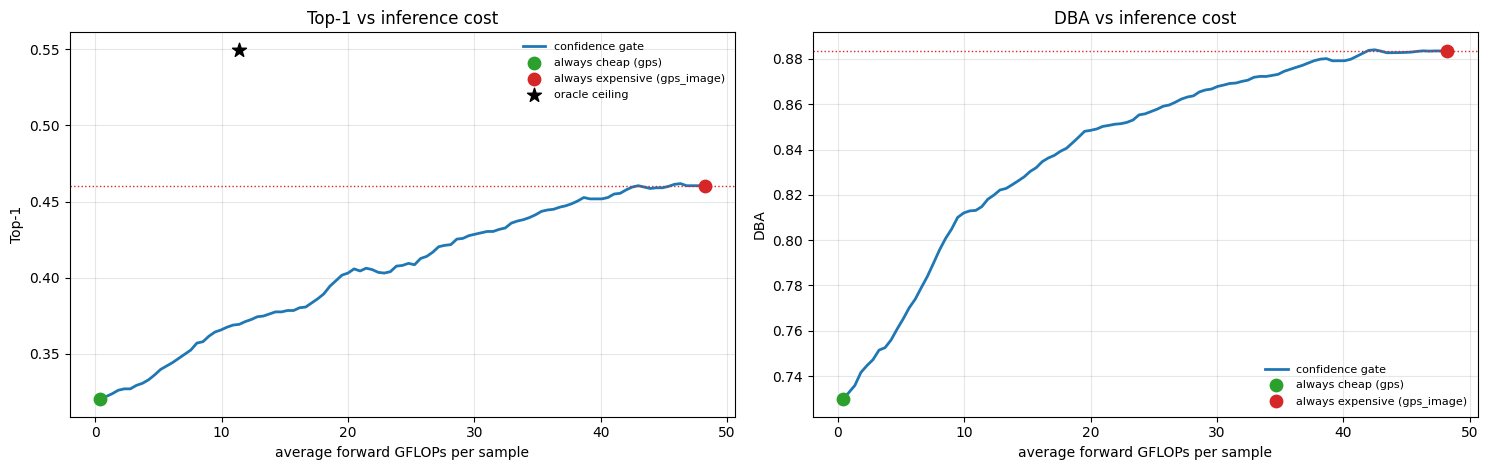

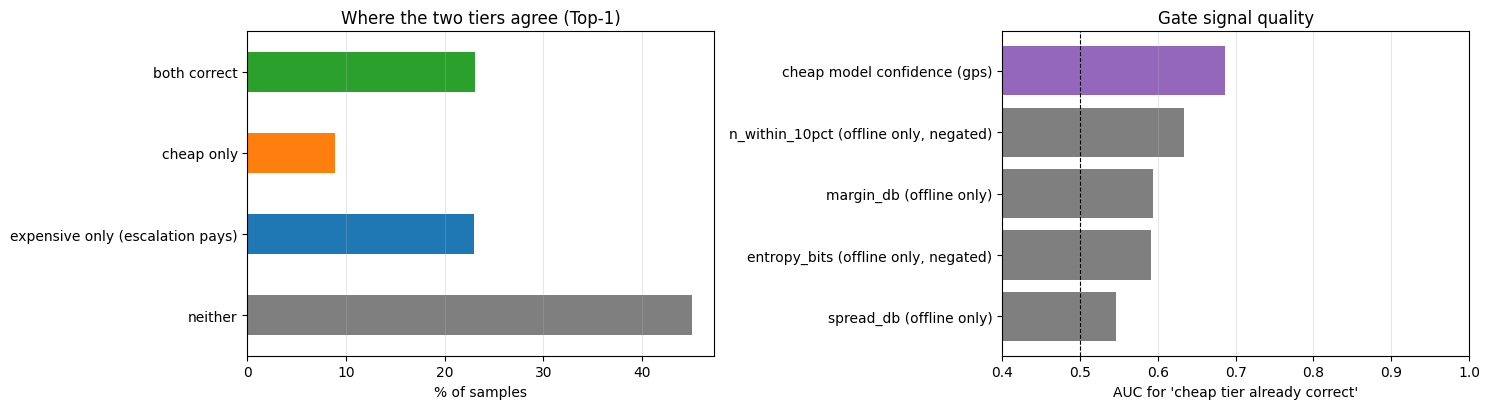

plots -> /kaggle/working/outputs/oracle_routing/plots


In [31]:
import matplotlib.pyplot as plt

P = OUT / "plots"
fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))

for a, col, base in ((ax[0], "Top-1", exp_acc), (ax[1], "DBA", ed.mean())):
    a.plot(sweep.GFLOPs, sweep[col], lw=2, label="confidence gate")
    a.scatter([GFLOPS[CHEAP]], [sweep[col].iloc[0]], s=80, c="tab:green",
              zorder=5, label=f"always cheap ({CHEAP})")
    a.scatter([GFLOPS[EXPENSIVE]], [base], s=80, c="tab:red", zorder=5,
              label=f"always expensive ({EXPENSIVE})")
    a.axhline(base, color="tab:red", ls=":", lw=1)
    if col == "Top-1":
        a.scatter([cost_oracle], [oracle_acc], s=110, marker="*", c="k",
                  zorder=6, label="oracle ceiling")
    a.set(xlabel="average forward GFLOPs per sample", ylabel=col,
          title=f"{col} vs inference cost")
    a.grid(alpha=.3)
    a.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.savefig(P / "accuracy_vs_cost.png", dpi=150)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(15, 4.2))
(quad / len(M) * 100).plot.barh(ax=ax[0], color=["tab:green", "tab:orange",
                                                 "tab:blue", "tab:grey"])
ax[0].set(xlabel="% of samples", title="Where the two tiers agree (Top-1)")
ax[0].grid(alpha=.3, axis="x")
ax[0].invert_yaxis()

r = res.dropna()
ax[1].barh(r.signal, r.AUC, color=["tab:purple" if "confidence" in s else "tab:grey"
                                   for s in r.signal])
ax[1].axvline(0.5, color="k", lw=.8, ls="--")
ax[1].set(xlabel="AUC for 'cheap tier already correct'", xlim=(0.4, 1.0),
          title="Gate signal quality")
ax[1].grid(alpha=.3, axis="x")
ax[1].invert_yaxis()
plt.tight_layout()
plt.savefig(P / "agreement_and_signals.png", dpi=150)
plt.show()
print(f"plots -> {P}")

## 11. Verdict

Generated from the measured numbers, including when they say the contribution is
not there.

In [32]:
L = []
gain_over_fixed = oracle_acc - exp_acc
r_t1 = first_reaching("Top-1", exp_acc)
r_dba = first_reaching("DBA", ed.mean())
conf_auc = float(res[res.signal.str.contains("confidence")].AUC.iloc[0])
best_off = res[res.signal.str.contains("offline")].AUC.max()

L.append(f"**Headroom.** {quad['expensive only (escalation pays)'] / len(M) * 100:.1f}% of "
         f"samples are wrong under {CHEAP} but right under {EXPENSIVE}, so escalation can "
         f"help there. {quad['cheap only'] / len(M) * 100:.1f}% are the reverse -- escalation "
         f"actively *hurts* them -- and {quad['neither'] / len(M) * 100:.1f}% are beyond both.")

L.append(f"**Oracle ceiling.** A router with perfect foresight reaches Top-1 "
         f"{oracle_acc:.4f} at {cost_oracle:.2f} GFLOPs, against {exp_acc:.4f} at "
         f"{GFLOPS[EXPENSIVE]:.2f} for always-{EXPENSIVE}: {gain_over_fixed:+.4f} Top-1 "
         f"for {(1 - cost_oracle / GFLOPS[EXPENSIVE]) * 100:.0f}% less compute. "
         + ("That is real headroom." if gain_over_fixed > 0.005 else
            "The accuracy gain is negligible, so routing's case rests entirely on "
            "the compute saving."))

if r_dba is not None:
    L.append(f"**Realisable gate.** Escalating by the cheap model's own confidence "
             f"matches always-{EXPENSIVE} DBA at {r_dba.escalated_frac * 100:.0f}% of "
             f"samples escalated, i.e. {r_dba.GFLOPs:.2f} against "
             f"{GFLOPS[EXPENSIVE]:.2f} GFLOPs -- "
             f"**{(1 - r_dba.GFLOPs / GFLOPS[EXPENSIVE]) * 100:.0f}% of the compute "
             f"removed at equal DBA**. "
             + ("That is a contribution worth building." if r_dba.escalated_frac < 0.8 else
                "But it escalates almost everything, so the saving is thin."))
else:
    L.append(f"**Realisable gate.** The confidence gate never reaches "
             f"always-{EXPENSIVE} DBA (best {sweep.DBA.max():.4f} against "
             f"{ed.mean():.4f}). **Routing on confidence cannot match the best fixed "
             f"configuration**, so on this evidence the adaptive contribution as framed "
             f"does not hold up.")

L.append(f"**Gate signal.** The cheap model's confidence gives AUC {conf_auc:.3f} for "
         f"predicting that the cheap tier already suffices"
         + (f"; the best offline difficulty measure reaches {best_off:.3f}, so a "
            f"difficulty-aware gate could add at most "
            f"{best_off - conf_auc:+.3f} AUC -- and cannot be deployed, since those "
            f"measures are computed from the target."
            if np.isfinite(best_off) else ".")
         + (" Confidence alone is a usable signal." if conf_auc > 0.65 else
            " That is weak, which caps how well any confidence gate can work and is "
            "the first thing to improve."))

L.append("**Caveats.** Measured on the validation split, in-domain by construction. "
         "The ablation showed camera generalises badly to the unseen scenario 31, "
         "where GPS alone is the better configuration, so a gate tuned here may "
         "escalate exactly the wrong way on the 48% of the test split that is "
         "scenario 31. Difficulty measures are target-derived and offline only.")

text = "\n\n".join(L)
print(text)
(OUT / "verdict.md").write_text(text)

**Headroom.** 22.9% of samples are wrong under gps but right under gps_image, so escalation can help there. 8.9% are the reverse -- escalation actively *hurts* them -- and 45.0% are beyond both.

**Oracle ceiling.** A router with perfect foresight reaches Top-1 0.5496 at 11.36 GFLOPs, against 0.4604 at 48.24 for always-gps_image: +0.0892 Top-1 for 76% less compute. That is real headroom.

**Realisable gate.** Escalating by the cheap model's own confidence matches always-gps_image DBA at 87% of samples escalated, i.e. 42.02 against 48.24 GFLOPs -- **13% of the compute removed at equal DBA**. But it escalates almost everything, so the saving is thin.

**Gate signal.** The cheap model's confidence gives AUC 0.686 for predicting that the cheap tier already suffices; the best offline difficulty measure reaches 0.633, so a difficulty-aware gate could add at most -0.053 AUC -- and cannot be deployed, since those measures are computed from the target. Confidence alone is a usable signal.

**Ca

1349

## 12. Secondary split and outputs

In [33]:
# the same comparison on adaptation, which contains the unseen scenario 31
long_a, Ma = build_matrix(SECONDARY_SPLIT)
Ma.to_csv(OUT / f"per_sample_{SECONDARY_SPLIT}.csv", index=False)
rows = []
for slug in (CHEAP, EXPENSIVE):
    for scn, g in Ma.groupby("scenario"):
        rows.append({"configuration": slug, "scenario": scn, "n": len(g),
                     "Top-1": g[f"correct1__{slug}"].mean(),
                     "DBA": g[f"dba__{slug}"].mean()})
sec = pd.DataFrame(rows)
sec.to_csv(OUT / f"tiers_by_scenario_{SECONDARY_SPLIT}.csv", index=False)
print(f"{SECONDARY_SPLIT} -- the two tiers per scenario "
      f"(scenario 31 is unseen in training):\n")
print(sec.round(4).to_string(index=False))

print(f"\n\n{OUT}:")
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        print(f"  {p.relative_to(OUT)}  ({p.stat().st_size / 1e3:.1f} KB)")

adaptation -- the two tiers per scenario (scenario 31 is unseen in training):

configuration   scenario  n  Top-1    DBA
          gps scenario31 50   0.04 0.2640
          gps scenario32 25   0.36 0.6800
          gps scenario33 25   0.44 0.8720
    gps_image scenario31 50   0.00 0.0200
    gps_image scenario32 25   0.56 0.9253
    gps_image scenario33 25   0.56 0.9173


/kaggle/working/outputs/oracle_routing:
  confidence_gate_sweep.csv  (6.2 KB)
  gate_signal_auc.csv  (0.3 KB)
  per_sample_adaptation.csv  (25.1 KB)
  per_sample_val.csv  (722.3 KB)
  plots/accuracy_vs_cost.png  (112.6 KB)
  plots/agreement_and_signals.png  (78.4 KB)
  predictions/adaptation_gps.csv  (10.7 KB)
  predictions/adaptation_gps_image.csv  (11.2 KB)
  predictions/adaptation_gps_image_lidar.csv  (11.8 KB)
  predictions/adaptation_gps_lidar.csv  (11.3 KB)
  predictions/adaptation_gps_radar.csv  (11.3 KB)
  predictions/adaptation_gps_radar_image.csv  (11.8 KB)
  predictions/adaptation_gps_radar_image_lidar.csv 